# Local Vol Calibration (Dupire method)

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the classic process of calibration of the Local Vol by the Dupire method. We assume that an implied vol model has been calibrated previously. We feed that model in an implementation of the Dupire formula that samples the local vol on a fine grid of expiries and strikes. That local vol matrix is then interpolated for use in numerical methods (MC and PDE).

In [ ]:
import datetime as dt
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.maths.metrics import rmse
from sdevpy.analytics import black
from sdevpy.market import provider as mdp
from sdevpy.volatility.impliedvol import impliedvol_factory
from sdevpy.volatility.localvol import localvol_factory as lvf
from sdevpy.volatility.localvol.dupire_calib import calib_lv_dupire
from sdevpy.utilities import timegrids
from sdevpy.utilities.timegrids import TimeGridBucket
from sdevpy.utilities import dates as dts
from sdevpy.utilities.algos import upper_bound
from sdevpy.montecarlo import mcpricer as mc
from sdevpy.pde import forwardpde as pde

print("SDevPy version: " + sd.__version__)

SDevPy version: 1.0.5


### Retrieve Implied Vol Model
The LV calibration, here according to the Dupire method, will need to start from an implied volatility surface model. Here we load a model that has been calibrated to a certain market in a previous step. For later purposes we also retrieve the forward curve and define a set of test expiries at which we will compare the LV based numerical prices to the closed-form targets (as calculated with the implied vol model).

In [ ]:
name, valdate, model_name = "ABC", dt.datetime(2025, 12, 15), 'LogMix3'
md = mdp.MarketDataFileProvider()
test_tenors = ['1M', '3M', '6M', '9M', '1Y', '2Y'] # Must have len = 6 for display reasons
n_test_strikes = 10
lw_p = 0.05 # Low percentile strike
up_p = 1.0 - lw_p # High percentile strike

# Retrieve pre-calibrated implied vol surface
iv_surface = impliedvol_factory.get_impliedvol(name, valdate, model_name)

# Retrieve forward curve
fwd_curve = mdp.get_eq_forward_curves([name], valdate, md)[0]

# Define expiries at which we will observe the accuracy
test_expiries = [dts.advance(valdate, tenor) for tenor in test_tenors]
test_times =  timegrids.model_time(valdate, test_expiries)

# Calculate observation strikes and closed-form straddle prices/IVs
percentiles = np.linspace(lw_p, up_p, n_test_strikes)
n_quantiles = norm.ppf(percentiles)
fwds, strikes, cf_prices, cf_ivs = [], [], [], []
for expiry, time in zip(test_expiries, test_times, strict=True):
    fwd = fwd_curve.value(expiry)
    atm = iv_surface.black_volatility(time, fwd, fwd)
    stdev = atm * np.sqrt(time)
    exp_strikes = fwd * np.exp(-0.5 * stdev * stdev + stdev * n_quantiles)
    call = iv_surface.forward_price(time, exp_strikes, True, fwd)
    put = iv_surface.forward_price(time, exp_strikes, False, fwd)
    fwds.append(fwd)
    strikes.append(exp_strikes)
    cf_prices.append(call + put)
    cf_ivs.append(iv_surface.black_volatility(time, exp_strikes, fwd))

print("CF prices/vols calculated")

CF prices/vols calculated


### Local Vol Calibration (Dupire)
Now we use the implied volatility surface calibrated to market data in the previous section to derive the corresponding local volatility using the Dupire method.

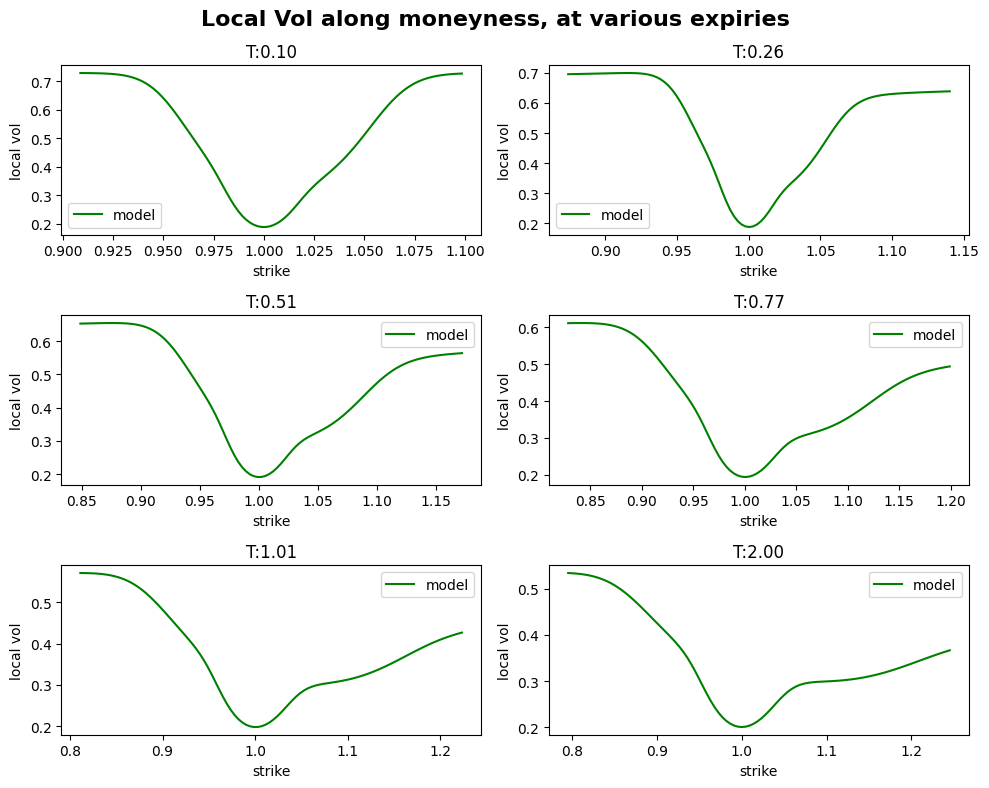

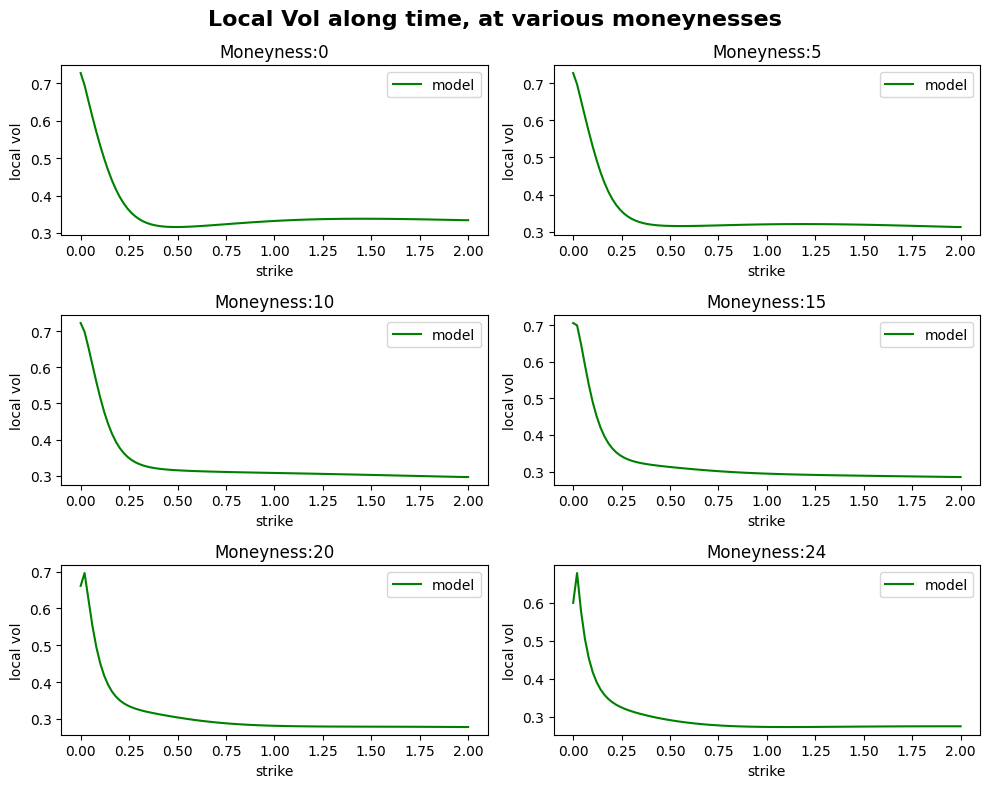

In [3]:
# Granularity of the LV matrix
points_per_year = 50
n_strikes = 100

# Define calibration horizon
tmax = test_times.max()

# Define time grid by time buckets
time_buckets = []
time_buckets.append(TimeGridBucket(start=0.0, end=0.1, n_points=20))
time_buckets.append(TimeGridBucket(start=0.1, end=0.5, n_points=40))
time_buckets.append(TimeGridBucket(start=0.5, end=1.0, n_points=25))
time_buckets.append(TimeGridBucket(start=1.0, end=10.0, n_points=100))

# Launch Dupire calibration
lv_calib = calib_lv_dupire(iv_surface, points_per_year=points_per_year, n_strikes=n_strikes,
                           tmax=tmax)#, time_buckets=time_buckets, low_percent=0.01)#, t_grid=lv_calib_times)
lv_t = lv_calib['t_grid']
lv_moneyness = lv_calib['moneyness']
lv_matrix = lv_calib['lv_matrix']
lv = lv_calib['lv']

# View the LV along the strike at several expiries
t_idx = [upper_bound(lv_t, tp) for tp in test_times]
plot_lv_t = lv_t[t_idx]

n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = plot_lv_t[exp_idx]
        ax.plot(lv_moneyness[exp_idx], lv_matrix[exp_idx], label="model", color='green')
        ax.set_title(f"T:{expiry:.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along moneyness, at various expiries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# View LV along the expiry at several moneynesses
m_idx = [0, 5, 10, 15, 20, 24]
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        k_idx = n_cols * i + j
        k_idx = m_idx[k_idx]
        lv_ = [lv_matrix[tidx][k_idx] for tidx in range(len(lv_t))]
        ax.plot(lv_t, lv_, label="model", color='green')
        ax.set_title(f"Moneyness:{k_idx}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along time, at various moneynesses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Compare MC prices to IV model

In [4]:
def analyse_numerical_prices(num_prices):
    """ Small helper to calculate implied vols from numerical prices and RMSEs to closed-form """
    num_ivs, rmses = [], []
    for i in range(len(test_expiries)):
        expiry = test_times[i]
        fwd = fwds[i]
        exp_strikes = strikes[i]
        num_price = num_prices[i]
        num_iv = []
        for j in range(len(exp_strikes)):
            strike = exp_strikes[j]
            try:
                call_price = (num_price[j] - strike + fwd) / 2.0 # Call from straddle
                iv = black.implied_vol(expiry, strike, True, fwd, call_price)
            except Exception:
                iv = np.nan
            num_iv.append(iv)

        vol_rmse = rmse(num_iv, cf_ivs[i])
        num_ivs.append(num_iv)
        rmses.append(vol_rmse)

    return num_ivs, np.asarray(rmses)

Time steps: 250
Number simulations: 20000
Runtime(Generate spot paths): 1.7s
Runtime(Interpolate to event grid): 0.0s
Runtime(Payoff calculation): 0.0s


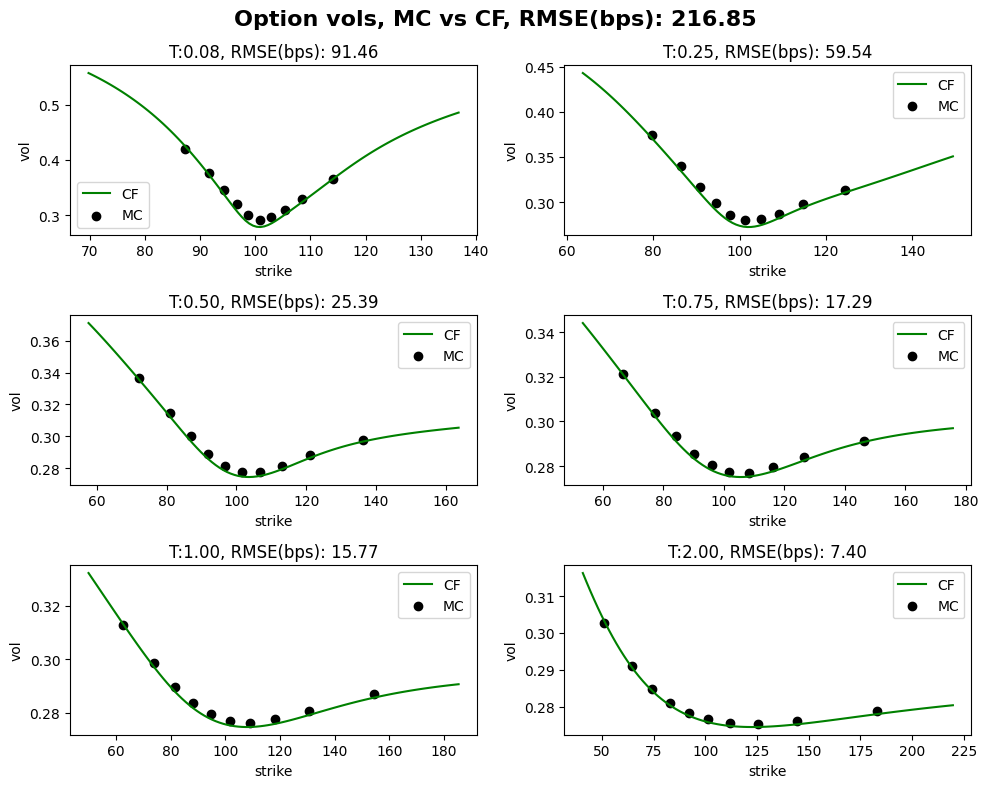

In [5]:
n_steps, n_paths = 250, 20000

print(f"Time steps: {n_steps}")
print(f"Number simulations: {n_paths}")

# Calculate MC prices
mc_prices = mc.price_vanilla_surface(valdate, test_expiries, strikes, name, lv=lv, n_paths=n_paths,
                                     n_timesteps=n_steps, constr_type='brownianbridge', rng_type='sobol')

# Calculate implied vols and accuracy
mc_prices = np.asarray(mc_prices)
mc_ivs, mc_rmses = analyse_numerical_prices(mc_prices)
mc_rmse = mc_rmses.sum()

## Plot ##
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = test_expiries[exp_idx]
        t = test_times[exp_idx]
        fwd = fwds[exp_idx]
        exp_strikes = strikes[exp_idx]

        # Generate 'continuous' plot for closed-form
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        cf_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        cf_vols = iv_surface.black_volatility(t, cf_strikes, fwd)
        ax.plot(cf_strikes, cf_vols, label="CF", color='green')

        # Scatter for MC IVs
        ax.scatter(exp_strikes, mc_ivs[exp_idx], label="MC", color='black')

        ax.set_title(f"T:{t:.2f}, RMSE(bps): {10000.0 * mc_rmses[exp_idx]:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle(f'Option vols, MC vs CF, RMSE(bps): {10000.0 * mc_rmse:,.2f}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Compare PDE prices to IV model

Time steps: 250
Spot steps: 500


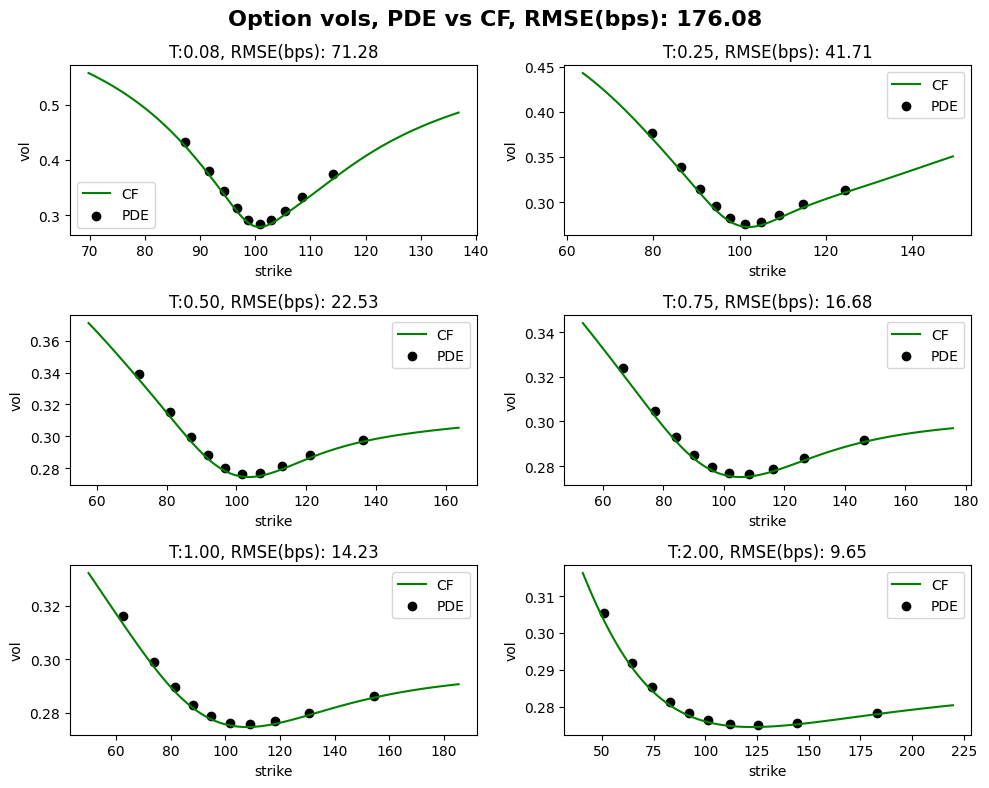

In [6]:
n_timesteps, n_meshes, scheme = 250, 500, 'rannacher'

print(f"Time steps: {n_timesteps}")
print(f"Spot steps: {n_meshes}")

# Calculate PDE prices
pde_prices = pde.price_vanilla_surface(valdate, test_expiries, strikes, fwd_curve, lv,
                                       n_timesteps=n_timesteps, n_meshes=n_meshes,
                                       scheme=scheme, iv_surface=iv_surface)

# Calculate implied vols and accuracy
pde_ivs, pde_rmses = analyse_numerical_prices(pde_prices)
pde_rmse = pde_rmses.sum()

## Plot ##
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = test_expiries[exp_idx]
        t = test_times[exp_idx]
        fwd = fwds[exp_idx]
        exp_strikes = strikes[exp_idx]

        # Generate 'continuous' plot for closed-form
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        cf_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        cf_vols = iv_surface.black_volatility(t, cf_strikes, fwd)
        ax.plot(cf_strikes, cf_vols, label="CF", color='green')

        # Scatter for MC IVs
        ax.scatter(exp_strikes, pde_ivs[exp_idx], label="PDE", color='black')

        ax.set_title(f"T:{t:.2f}, RMSE(bps): {10000.0 * pde_rmses[exp_idx]:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle(f'Option vols, PDE vs CF, RMSE(bps): {10000.0 * pde_rmse:,.2f}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Dump to file
file = lvf.data_file(name, valdate, 'Matrix')
lv.valdate = lv.snapdate = valdate
lv.dump(file)
print(f"LV written to file: {file}")

LV written to file: C:\Code\SDev.Python\datasets\localvol\ABC\20251215-000000.Matrix.json
